In [14]:
import pandas as pd
import re

## 1. Data Parsing
Dữ liệu thô ban đầu có dạng văn bản lồng ghép nhãn cảm xúc: `{ENTITY#ATTRIBUTE, polarity}`. 
* **Ý tưởng:** Để tương thích với mô hình Softmax, bài toán được chuyển đổi (Flatten) thành dạng ma trận nhãn. 
* Hệ thống trích xuất 12 cặp khía cạnh (Aspects) tiêu biểu (như `FOOD#QUALITY`, `SERVICE#GENERAL`, `RESTAURANT#PRICES`) thành 12 cột biến mục tiêu độc lập.
* Mỗi aspect được gán một trong 4 giá trị số học:
  * `0`: Null
  * `1`: Positive
  * `2`: Negative
  * `3`: Neutral

In [15]:
aspects = [
    'RESTAURANT#GENERAL', 'RESTAURANT#PRICES', 'RESTAURANT#MISCELLANEOUS',
    'FOOD#QUALITY', 'FOOD#PRICES', 'FOOD#STYLE_OPTIONS',
    'DRINKS#QUALITY', 'DRINKS#PRICES', 'DRINKS#STYLE_OPTIONS',
    'AMBIENCE#GENERAL', 'SERVICE#GENERAL', 'LOCATION#GENERAL'
]

sentiment_map = {
    'positive': 1,
    'negative': 2,
    'neutral': 3
}

def preprocess_and_parse(file_path):
    results = []
    
    with open(file_path, 'r', encoding='utf-8') as f:
        content = f.read()
        blocks = re.split(r'\n#\d+\n', content)
        
        for block in blocks:
            lines = block.strip().split('\n')
            if len(lines) < 2: continue
            
            text = lines[0].strip()
            label_line = lines[-1].strip()
            
            row = {'review_text': text}
            for asp in aspects:
                row[asp] = 0
            
            matches = re.findall(r'\{(.*?), (.*?)\}', label_line)
            
            for asp_raw, sent_raw in matches:
                asp_clean = asp_raw.strip().upper().replace('&', '_')
                sent_clean = sent_raw.strip().lower()
                
                if asp_clean in aspects and sent_clean in sentiment_map:
                    row[asp_clean] = sentiment_map[sent_clean]
            
            results.append(row)
            
    return pd.DataFrame(results)

In [16]:
df_train = preprocess_and_parse(file_path='./data/1-VLSP2018-SA-Restaurant-train-(7-3-2018).txt')
df_train

,review_text,RESTAURANT#GENERAL,RESTAURANT#PRICES,RESTAURANT#MISCELLANEOUS,FOOD#QUALITY,FOOD#PRICES,FOOD#STYLE_OPTIONS,DRINKS#QUALITY,DRINKS#PRICES,DRINKS#STYLE_OPTIONS,AMBIENCE#GENERAL,SERVICE#GENERAL,LOCATION#GENERAL
0,﻿#1,0,0,0,3,0,3,0,0,0,0,0,0
1,"_Hương vị thơm ngon, ăn cay cay rất thích, nêm...",1,3,0,1,3,1,0,0,0,1,2,0
2,- 1 bàn tiệc hoành tráng 3 đứa ăn no muốn tắt ...,1,0,1,1,1,1,0,0,0,2,1,2
3,- Các bạn nhìn cái chảo này có to không 🙄🙄🙄- T...,1,0,0,1,0,1,0,0,0,0,0,0
4,"- Cháo: có nhiều hương cho các bạn chọn, nhưng...",0,0,0,1,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2956,Y hệt vị đà lạt luôn,0,0,0,1,0,0,0,0,0,0,0,0
2957,"Yaourt trái cây mát lạnh, có thêm viên kem ở t...",0,0,0,1,3,1,0,0,0,0,0,2
2958,Zumi.... zumi lễ vẫn bán nhé mọi người,1,0,1,0,0,0,0,0,0,0,0,0
2959,Set này có 2 tầng bánh và 1 ấm trà mà chỉ có 1...,1,1,0,0,0,0,0,0,0,1,0,0


## 2. Text Preprocessing

Pipeline tiền xử lý bao gồm các bước:
* **Loại bỏ Emoji:** Sử dụng thư viện `emoji` để loại bỏ các biểu tượng cảm xúc và thay thế bằng khoảng trắng, tránh hiện tượng dính chữ (vd: "ngon👍quá" -> "ngon quá").
* **Chuẩn hóa cơ bản:** Chuyển toàn bộ văn bản về chữ thường (lowercase), loại bỏ dấu câu (punctuation) và chuẩn hóa khoảng trắng.
* **Tách từ tiếng Việt (Word Segmentation):** Tích hợp thư viện `underthesea` để gom các âm tiết thành từ ghép có nghĩa (vd: "không gian" -> "không_gian", "phục vụ" -> "phục_vụ"). Điều này giúp mô hình hiểu đúng ngữ cảnh và giảm nhiễu cho bước sau.

In [17]:
import string
from underthesea import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
import emoji

In [18]:
def preprocess_and_segment(text):
    text = text.lower()
    text = emoji.replace_emoji(text, replace=' ')
    text = re.sub(f'[{re.escape(string.punctuation)}]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    segmented_text = word_tokenize(text, format="text")
    
    return segmented_text

print("Đang tiến hành tiền xử lý và tách từ...")
df_train['clean_text'] = df_train['review_text'].apply(preprocess_and_segment)

Đang tiến hành tiền xử lý và tách từ...


## 3. Feature Extraction
* Chuyển đổi ngôn ngữ tự nhiên thành vector số học bằng **TF-IDF Vectorizer**.
* Sử dụng N-grams với các hyperparameter:
    - `ngram_range=(1, 2)`: tham số này quyết định độ dài của cụm từ vectorizer sẽ học, cực kỳ quan trọng bắt được ngữ cảnh phủ định
    - `max_features=5000`: mô hình chỉ giữ lại đúng 5000 từ/cụm từ có tần số xuất hiện cao nhất trong tập train
    - `min_df=2`: tham số yêu cầu một từ phải xuất hiện trong ít nhất 2 câu review khác nhau thì mới được đưa vào từ điển.
    - `max_df=0.9`: tham số này làm mô hình bỏ qua tất cả những từ xuất hiện ở nhiều hơn 90% số câu review.

In [19]:
print("Đang tiến hành vector hóa TF-IDF...")
tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=5000,
    min_df=2,
    max_df=0.9
)

X_train = tfidf_vectorizer.fit_transform(df_train['clean_text'])
y_train = df_train[aspects]

print(f"Kích thước ma trận đặc trưng : {X_train.shape}")

Đang tiến hành vector hóa TF-IDF...
Kích thước ma trận đặc trưng : (2961, 5000)


In [20]:
y_train

,RESTAURANT#GENERAL,RESTAURANT#PRICES,RESTAURANT#MISCELLANEOUS,FOOD#QUALITY,FOOD#PRICES,FOOD#STYLE_OPTIONS,DRINKS#QUALITY,DRINKS#PRICES,DRINKS#STYLE_OPTIONS,AMBIENCE#GENERAL,SERVICE#GENERAL,LOCATION#GENERAL
0,0,0,0,3,0,3,0,0,0,0,0,0
1,1,3,0,1,3,1,0,0,0,1,2,0
2,1,0,1,1,1,1,0,0,0,2,1,2
3,1,0,0,1,0,1,0,0,0,0,0,0
4,0,0,0,1,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
2956,0,0,0,1,0,0,0,0,0,0,0,0
2957,0,0,0,1,3,1,0,0,0,0,0,2
2958,1,0,1,0,0,0,0,0,0,0,0,0
2959,1,1,0,0,0,0,0,0,0,1,0,0


## 4. Modeling & Evaluating
* **Huấn luyện:** Áp dụng `MultiOutputClassifier` để bọc mô hình `LogisticRegression` (với `multi_class='multinomial'` và `class_weight='balanced'`), cho phép huấn luyện song song 12 mô hình Softmax cho 12 khía cạnh.

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier

In [22]:
softmax_base = LogisticRegression(
    multi_class='multinomial', 
    solver='lbfgs',
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

multi_target_model = MultiOutputClassifier(softmax_base, n_jobs=-1)

print("Bắt đầu huấn luyện 12 mô hình Softmax...")
multi_target_model.fit(X_train, y_train)
print("Huấn luyện hoàn tất thành công!")

Bắt đầu huấn luyện 12 mô hình Softmax...
Huấn luyện hoàn tất thành công!


**Evaluating:** 

- Kết quả dự đoán được xuất nhanh dưới dạng **Confusion Matrix**. Hệ thống tự động vẽ một lưới đồ thị 4x3 trực quan hiển thị hiệu suất phân loại của cả 4 lớp cho toàn bộ 12 khía cạnh, giúp nhanh chóng nhận diện điểm yếu của mô hình. 
- Các thông số Presion, Recall, F1-Score cho từng model Softmax Regression được xuất ra dưới dạng json

In [23]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import json
import matplotlib.pyplot as plt

target_names = ['Null (0)', 'Positive (1)', 'Negative (2)', 'Neutral (3)']
labels_list = [0, 1, 2, 3]

Đang parse tập dev....
Đang tiền xử lý và tách từ tập dev....
Đang vector hóa tập dev....
Đang chạy dự đoán trên tập dev...

BÁO CÁO ĐÁNH GIÁ TRÊN TẬP DEV


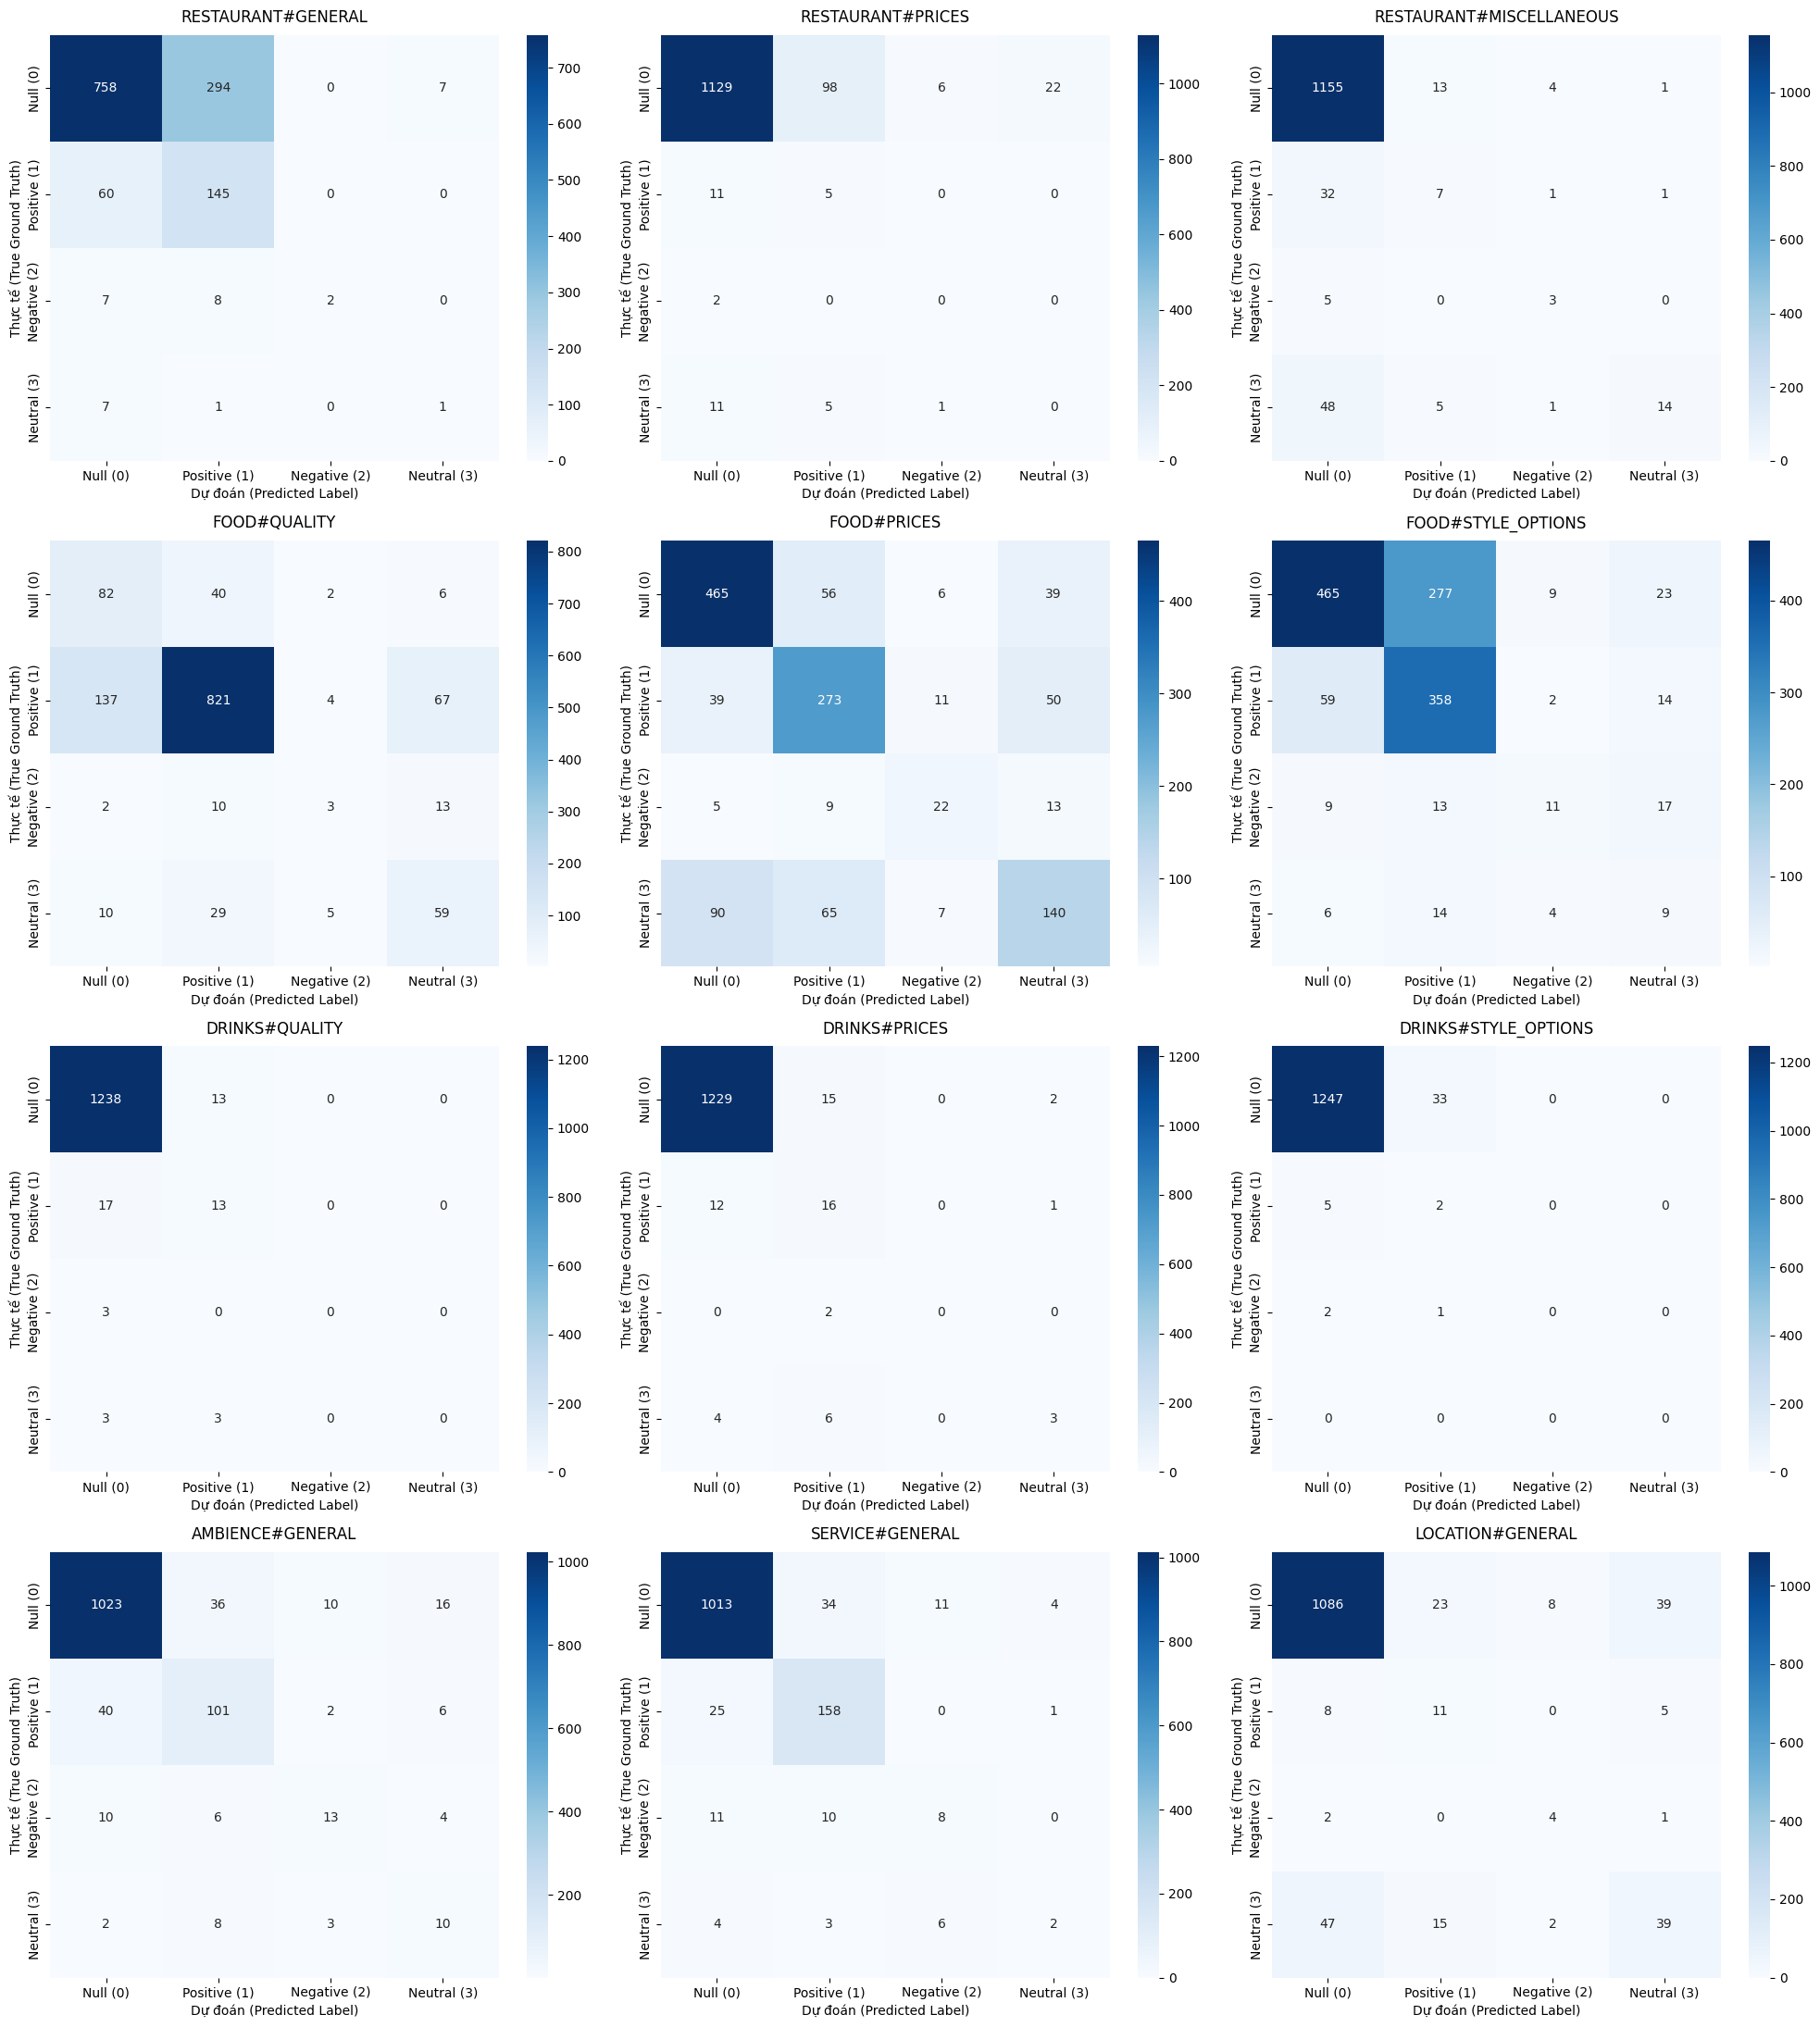

In [24]:
print('Đang parse tập dev....')
df_dev = preprocess_and_parse('./data/2-VLSP2018-SA-Restaurant-dev-(7-3-2018).txt')

print('Đang tiền xử lý và tách từ tập dev....')
df_dev['clean_text'] = df_dev['review_text'].apply(preprocess_and_segment)

print('Đang vector hóa tập dev....')
X_dev = tfidf_vectorizer.transform(df_dev['clean_text'])
y_dev = df_dev[aspects]

print("Đang chạy dự đoán trên tập dev...")
y_pred = multi_target_model.predict(X_dev)

print("\n" + "="*50)
print("BÁO CÁO ĐÁNH GIÁ TRÊN TẬP DEV")
print("="*50)

dev_report_dict = {}
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(20, 22))
axes = axes.flatten()

for i, aspect in enumerate(aspects):
        
    y_true = y_dev.iloc[:, i]
    y_predict = y_pred[:, i]
    
    report = classification_report(
        y_true, 
        y_predict, 
        labels=labels_list,
        target_names=target_names,
        zero_division=0,
        output_dict=True
    )
    
    dev_report_dict[aspect] = report
    
    cm = confusion_matrix(y_true, y_predict, labels=labels_list)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], xticklabels=target_names, yticklabels=target_names)
    axes[i].set_title(f'{aspect}', fontsize=12, pad=10)
    axes[i].set_ylabel('Thực tế (True Ground Truth)')
    axes[i].set_xlabel('Dự đoán (Predicted Label)')


plt.tight_layout()
plt.savefig('dev_12_aspects_confusion_matrices.png', dpi=300)

    
with open('test_evaluation_report.json', 'w', encoding='utf-8') as f:
    json.dump(dev_report_dict, f, ensure_ascii=False, indent=4)

Đang parse tập test....
Đang tiền xử lý và tách từ tập test....
Đang vector hóa tập test....
Đang chạy dự đoán trên tập test...

BÁO CÁO ĐÁNH GIÁ TRÊN TẬP TEST


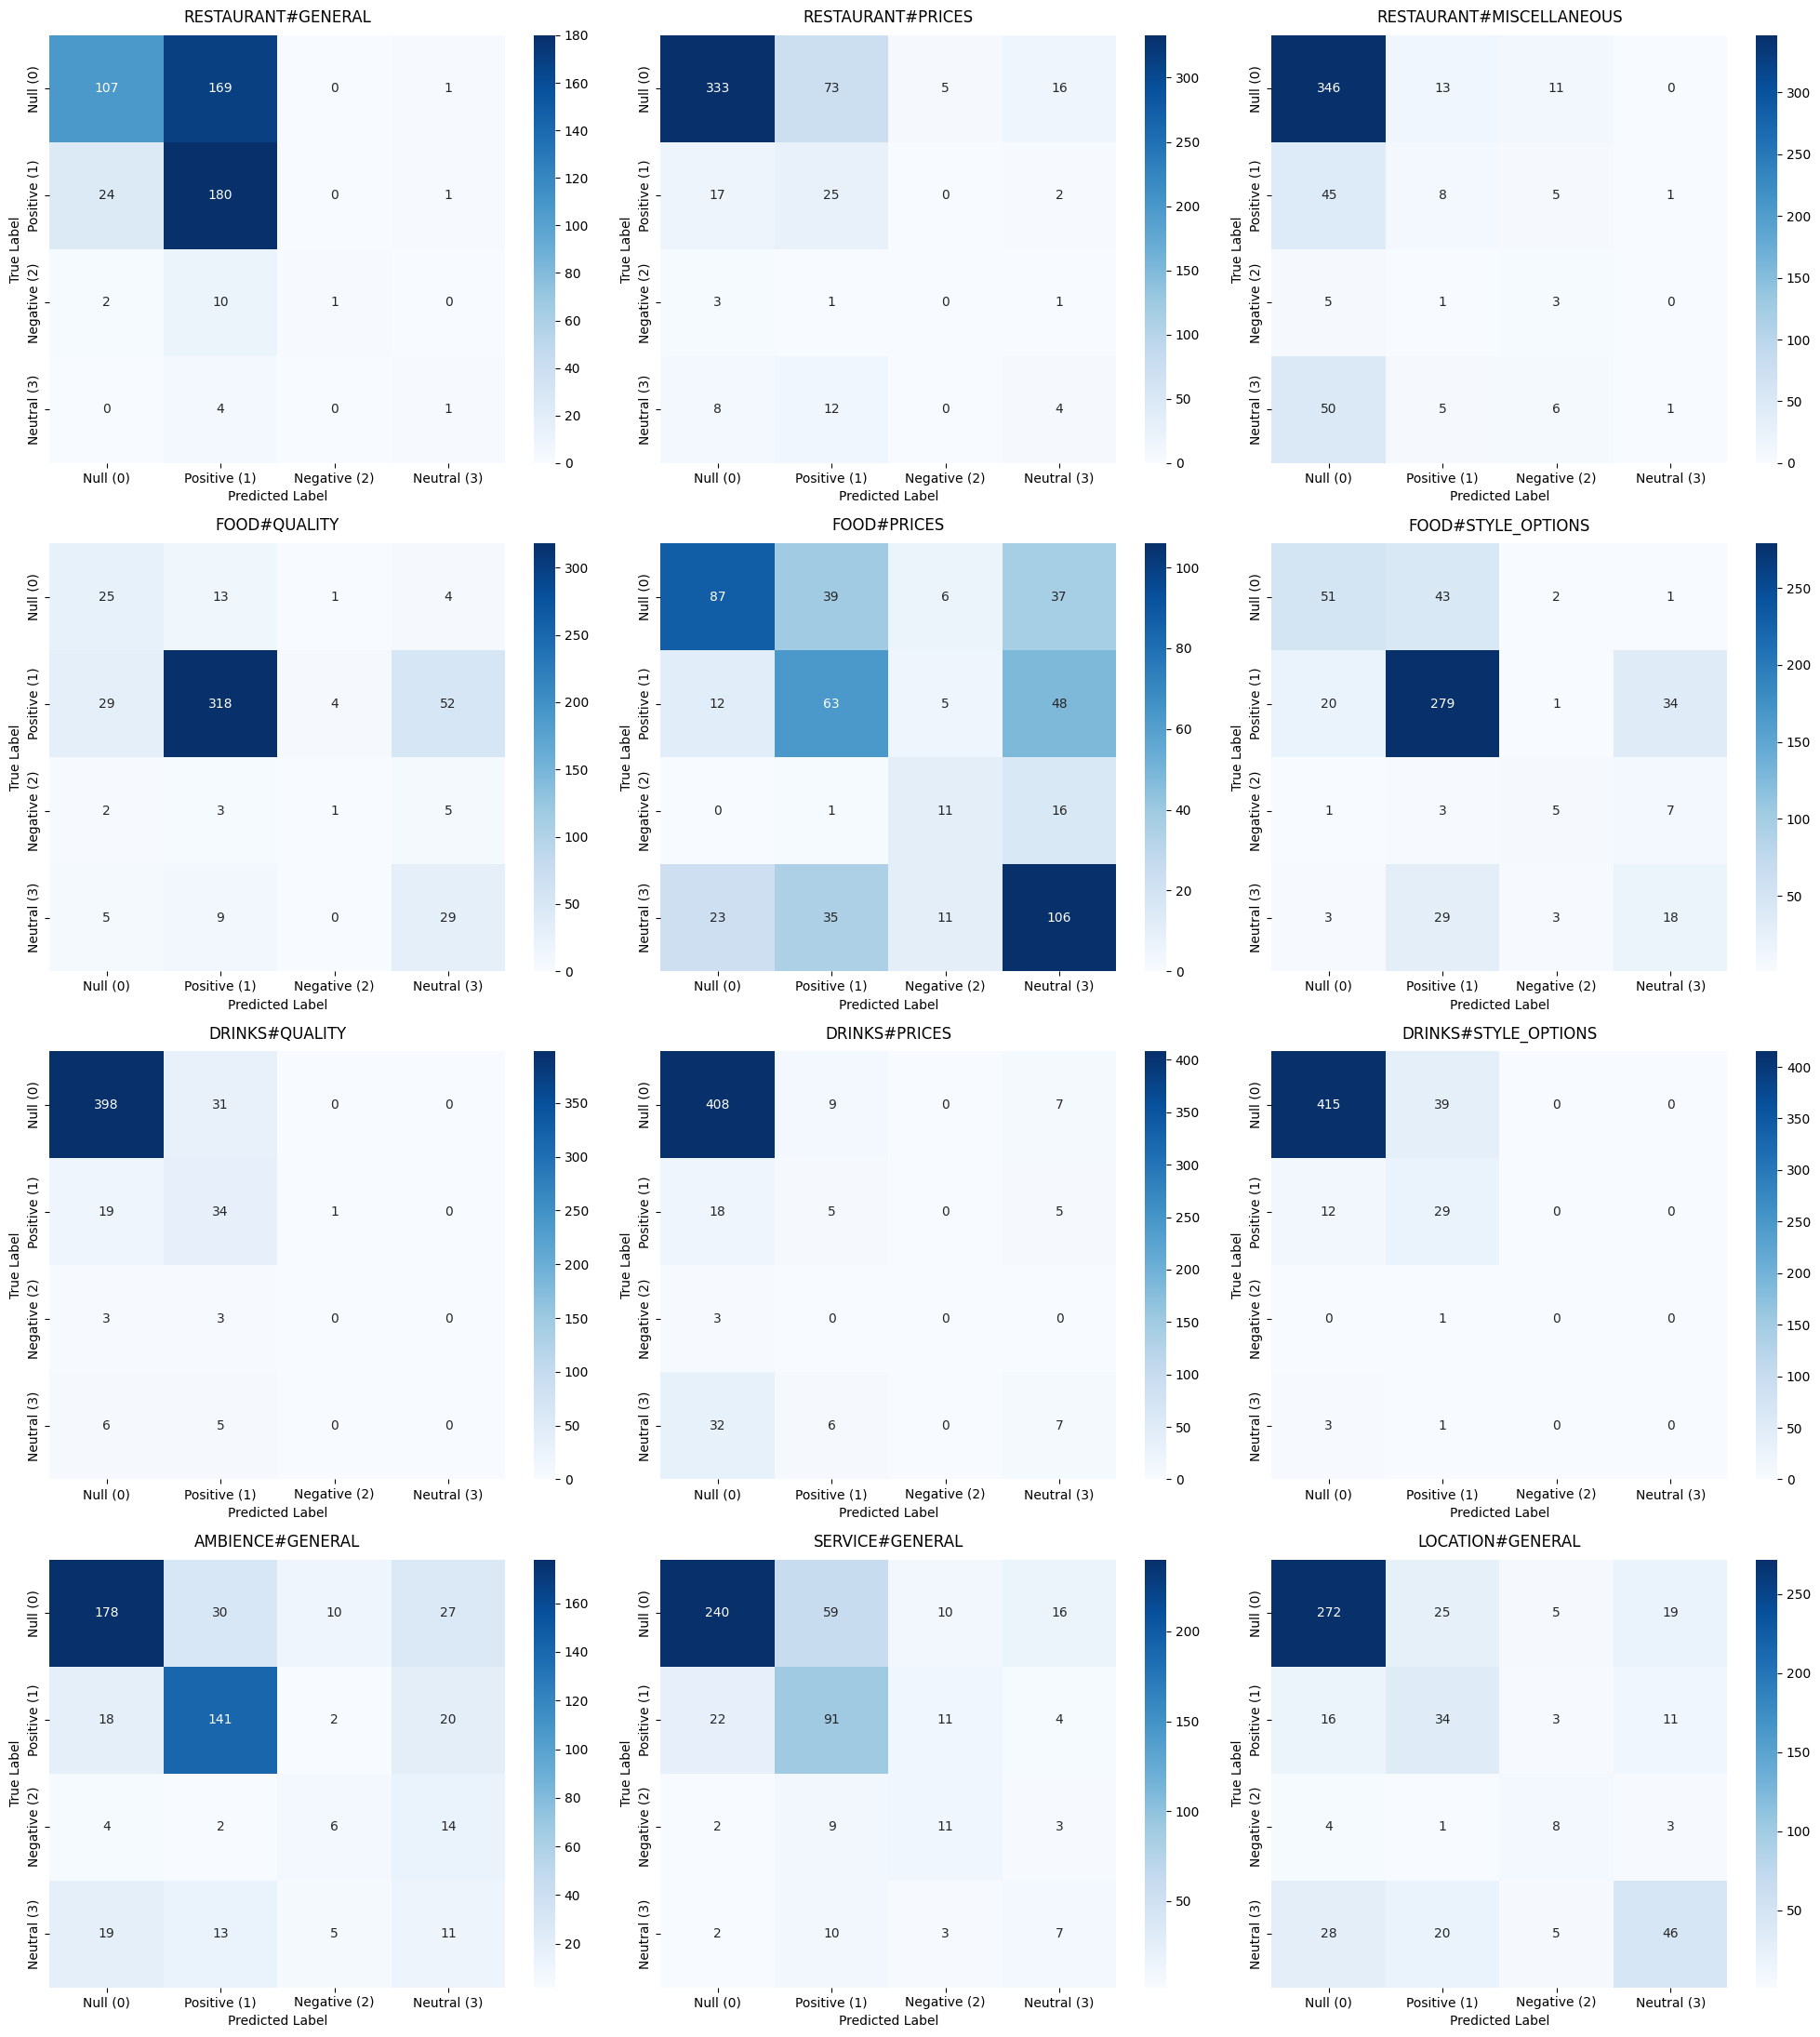

In [25]:
print('Đang parse tập test....')
df_test = preprocess_and_parse('./data/3-VLSP2018-SA-Restaurant-test-(8-3-2018).txt')

print('Đang tiền xử lý và tách từ tập test....')
df_test['clean_text'] = df_test['review_text'].apply(preprocess_and_segment)

print('Đang vector hóa tập test....')
X_test = tfidf_vectorizer.transform(df_test['clean_text'])
y_test = df_test[aspects]

print("Đang chạy dự đoán trên tập test...")
y_pred = multi_target_model.predict(X_test)

print("\n" + "="*50)
print("BÁO CÁO ĐÁNH GIÁ TRÊN TẬP TEST")
print("="*50)

test_report_dict = {}
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(20, 22))
axes = axes.flatten()

for i, aspect in enumerate(aspects):
    y_true = y_test.iloc[:, i]
    y_predict = y_pred[:, i]
    
    report = classification_report(
        y_true, 
        y_predict, 
        labels=labels_list,
        target_names=target_names,
        zero_division=0,
        output_dict=True
    )
    
    test_report_dict[aspect] = report
    
    cm = confusion_matrix(y_true, y_predict, labels=labels_list)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], xticklabels=target_names, yticklabels=target_names)
    axes[i].set_title(f'{aspect}', fontsize=12, pad=10)
    axes[i].set_ylabel('True Label')
    axes[i].set_xlabel('Predicted Label')


plt.tight_layout()
plt.savefig('test_12_aspects_confusion_matrices.png', dpi=300)

    
with open('test_evaluation_report.json', 'w', encoding='utf-8') as f:
    json.dump(test_report_dict, f, ensure_ascii=False, indent=4)

In [26]:
from sklearn.metrics import precision_score, recall_score, f1_score

def compute_aspect_metrics(y_true_df, y_pred_array, aspects, labels_list):
    rows = []
    for i, aspect in enumerate(aspects):
        y_true = y_true_df.iloc[:, i].values
        y_pred = y_pred_array[:, i]
        
        accuracy = (y_true == y_pred).mean()

        micro_precision = precision_score(y_true, y_pred, labels=labels_list, average='micro', zero_division=0)
        micro_recall    = recall_score(y_true, y_pred, labels=labels_list, average='micro', zero_division=0)
        micro_f1        = f1_score(y_true, y_pred, labels=labels_list, average='micro', zero_division=0)
        
        macro_precision = precision_score(y_true, y_pred, labels=labels_list, average='macro', zero_division=0)
        macro_recall    = recall_score(y_true, y_pred, labels=labels_list, average='macro', zero_division=0)
        macro_f1        = f1_score(y_true, y_pred, labels=labels_list, average='macro', zero_division=0)

        rows.append({
            'Aspect': aspect,
            'Accuracy': round(accuracy, 4),
            'Micro Precision': round(micro_precision, 4),
            'Micro Recall': round(micro_recall, 4),
            'Micro F1': round(micro_f1, 4),
            'Macro Precision': round(macro_precision, 4),
            'Macro Recall': round(macro_recall, 4),
            'Macro F1': round(macro_f1, 4),
        })
    
    return pd.DataFrame(rows).set_index('Aspect')


y_pred_test = multi_target_model.predict(X_test)
test_metrics = compute_aspect_metrics(y_test, y_pred_test, aspects, labels_list)
print("\n=== TEST SET ===")
display(test_metrics)


=== TEST SET ===


,Accuracy,Micro Precision,Micro Recall,Micro F1,Macro Precision,Macro Recall,Macro F1
Aspect,,,,,,,
RESTAURANT#GENERAL,0.578,0.578,0.578,0.578,0.6584,0.3853,0.3872
RESTAURANT#PRICES,0.724,0.724,0.724,0.724,0.3304,0.3787,0.3345
RESTAURANT#MISCELLANEOUS,0.716,0.716,0.716,0.716,0.4230,0.3550,0.3105
FOOD#QUALITY,0.746,0.746,0.746,0.746,0.4565,0.5340,0.4718
FOOD#PRICES,0.534,0.534,0.534,0.534,0.5038,0.5014,0.4968
FOOD#STYLE_OPTIONS,0.706,0.706,0.706,0.706,0.5557,0.5033,0.5233
DRINKS#QUALITY,0.864,0.864,0.864,0.864,0.3500,0.3893,0.3666
DRINKS#PRICES,0.840,0.840,0.840,0.840,0.3759,0.3241,0.3373
DRINKS#STYLE_OPTIONS,0.888,0.888,0.888,0.888,0.3449,0.4054,0.3654
